<a href="https://colab.research.google.com/github/Jespinoza-01/iele756-region-14/blob/main/notebooks/Tarea_0_Data_A%26P.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 0 --- IELE756
**Team members**: [Joaquin Espinoza] , [Antonia Becerra]

**Region**: [14] = "Región de los Ríos"

**Date**: [15 / 03 / 2026]



In [1]:
import pandas as pd
print("Hello, IELE756!")
print(f"pandas version: {pd.__version__}")

Hello, IELE756!
pandas version: 2.2.2


In [1]:
import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt

# Nombres de los archivos
zip_censo_path = "viv_hog_per_censo2024.zip"
parquet_filename = "personas_censo2024.parquet"

# 1. Extraer el archivo parquet si no existe en el entorno
if not os.path.exists(parquet_filename):
    print(f"Extrayendo {parquet_filename} del archivo ZIP...")
    with zipfile.ZipFile(zip_censo_path, 'r') as zip_ref:
        # Extraemos solo el archivo parquet en el directorio actual
        zip_ref.extract(parquet_filename, path=".")
    print("Extracción completada con éxito.")
else:
    print(f"El archivo {parquet_filename} ya se encuentra disponible.")

Extrayendo personas_censo2024.parquet del archivo ZIP...
Extracción completada con éxito.


## Part 1: Census 2024

Importancia del Código Ejecutado

- Carga selectiva: El archivo original del Censo es muy grande y pesado, al indicarle a Pandas que solo cargue 8 columnas específicas, optimizamos drásticamente el uso de memoria RAM.

- Revision incial (shape, info, head): Estas funciones nos confirman si la base se cargó completa, qué tipos de datos tenemos (números, textos, nulls) y cómo lucen estructuralmente los datos.

- Filtro regional: Reducir el dataframe de 18.5 millones de filas a solo las de nuestra región de interes aisla la población de estudio y hace que cualquier cálculo posterior sea eficiente.


Análisis de tu Output

- El tamaño del dataframe: El Shape nos confirma que cargamos 18,480,432 filas. Esto coincide con los ~19 millones esperados a nivel nacional. Además, el info() nos dice que esto consume 634.5 MB de memoria. Si hubiéramos cargado todas las columnas del censo sin filtrar, Colab probablemente habría colapsado.

- Tipos de variables: Si observamos los Data types, absolutamente todo es int32 o float64. Incluso variables que esperaríamos que fueran texto (como "sexo" o "nacionalidad") son códigos numéricos.

- Cantidad de Extranjeros: El código arrojó un 1.4% de residentes extranjeros. Inicialmente buscamos a partir de un parametro de texto: "Extranjero", lo cual nos arrojo 0% debido a que esta distincion era numerica. Se reviso el diccionario de variables y la distincion para ciudadanos extranjeros es con el valor "2".

In [12]:
# 1.1 Load
columnas_censo = ["region", "comuna", "sexo", "edad", "p27_nacionalidad", "p27_nacionalidad_rec", "escolaridad", "sit_fuerza_trabajo"]
persona = pd.read_parquet(parquet_filename, columns=columnas_censo)

# 1.2 Inspect
print(f"Shape (Nacional): {persona.shape}")
print("\nData types:\n", persona.dtypes)
print("\nInfo General:")
persona.info()
print("\nPrimeras 10 filas:")
display(persona.head(10))

# 1.3 Filter to your region (Región 14 - Los Ríos es código numérico)
my_region = persona[persona["region"] == 14]
print(f"\nRows in my region (14): {len(my_region):,}")

# 1.4 First look at nationality
distribucion_nacionalidad = my_region["p27_nacionalidad_rec"].value_counts(normalize=True)
foreign = distribucion_nacionalidad.get(2, 0)
print(f"\nPorcentaje de residentes extranjeros en Los Ríos: {foreign:.1%}")

Shape (Nacional): (18480432, 8)

Data types:
 region                    int32
comuna                    int32
sexo                      int32
edad                      int32
p27_nacionalidad          int32
p27_nacionalidad_rec      int32
escolaridad               int32
sit_fuerza_trabajo      float64
dtype: object

Info General:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18480432 entries, 0 to 18480431
Data columns (total 8 columns):
 #   Column                Dtype  
---  ------                -----  
 0   region                int32  
 1   comuna                int32  
 2   sexo                  int32  
 3   edad                  int32  
 4   p27_nacionalidad      int32  
 5   p27_nacionalidad_rec  int32  
 6   escolaridad           int32  
 7   sit_fuerza_trabajo    float64
dtypes: float64(1), int32(7)
memory usage: 634.5 MB

Primeras 10 filas:


,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0
5,4,4303,2,65,1,1,12,3.0
6,4,4303,1,58,1,1,15,1.0
7,11,11202,2,-66,-66,1,8,1.0
8,11,11202,1,-66,-66,1,5,1.0
9,11,11202,1,-66,-66,1,3,NaN



Rows in my region (14): 398,230

Porcentaje de residentes extranjeros en Los Ríos: 1.4%


### Part 2: ENO — Notifiable Diseases

Importancia del Código Ejecutado

- Lectura de formatos alternativos: El código nos permitió leer un CSV que no usa la típica coma, sino un punto y coma (;) como delimitador. Además, forzar la codificación utf-8-sig evitó que los caracteres especiales (como las tildes en "Sífilis" o "Ríos") se rompieran.

- Filtro basado en texto (Strings): A diferencia del Censo donde filtramos por un número, aquí la región venía como texto. El código aplicado permitió atrapar los registros de tu región sin importar si el ministerio escribió "Ríos" o "Rios".

- Agrupación y Visualización (value_counts + plot): Transformamos miles de filas sueltas en resúmenes visuales. Permitiendo un analisis profundo sin usar un gran esfuerzo en agrupar y calcular mentalmente miles de filas.

Análisis de tu Output

- DtypeWarning: Lo primero que resalta arriba en la consola es una advertencia de Pandas. Esto ocurre porque al cargar el archivo, Pandas revisó las primeras filas para determianr si las columnas eran texto o números, pero más adelante se encontró con tipos mezclados. En el mundo real, esto es un indicador clásico de datos "sucios" o mal tabulados. Para este análisis rápido no nos afecta, pero para un modelo de aprendizaje mas sofisticado, tendríamos que limpiar esas columnas obligatoriamente.

- Volumen de datos coherente: El total nacional marca 333,300 filas. De ese total, la región de los Ríos se queda con una muestra muy manejable de 5,581 registros.

- Comportamiento temporal anómalo (El gráfico de años): Al analizar el grafico las notificaciones se mantienen estables entre 2007 y 2016, pero de repente hay un aumento masivo en 2018 y 2019. Luego, en 2020 caen nuevamente.

- Perfil epidemiológico (Top 5 Enfermedades): El gráfico de barras horizontales nos dice mucho de la región. Tres de las cinco principales son de transmisión sexual (Sífilis, VIH, Infección gonocócica).

- Nacionalidad no notificada: La categoría más grande con 2,818 registros, dentro de la columna "nacionalidad", es "Desconocido", superando incluso a "Chile" (2,588). Esto es un hallazgo crítico: significa que en más del 50% de los casos históricos en la región, el centro de salud omitió registrar la nacionalidad del paciente.


/tmp/ipykernel_163/820566476.py:2: DtypeWarning: Columns (6,11,12,13,14,15,16,17,18,19,20,22,23,24,25,26,27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  eno = pd.read_csv("20241218_base_eno_final.csv", sep=";", encoding="utf-8-sig")


Total rows (Nacional ENO): 333,300
Rows in my region (ENO): 5,581


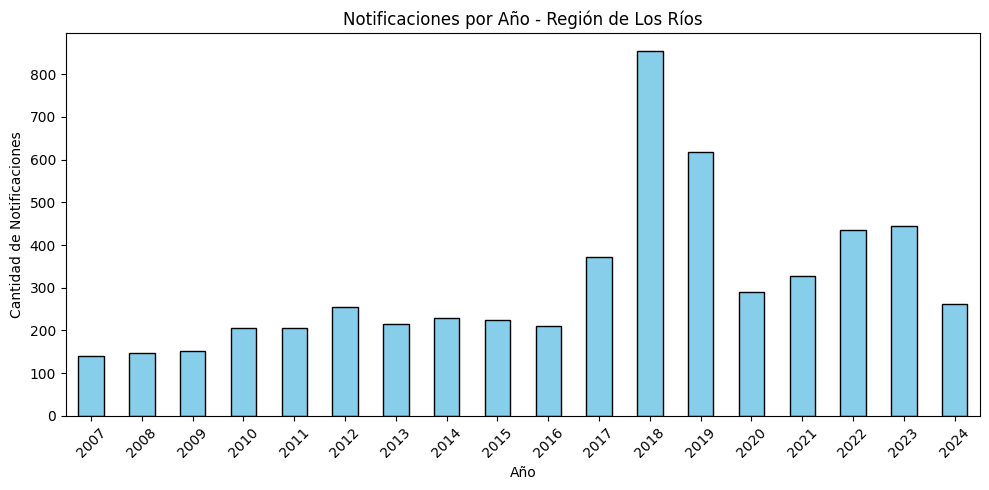

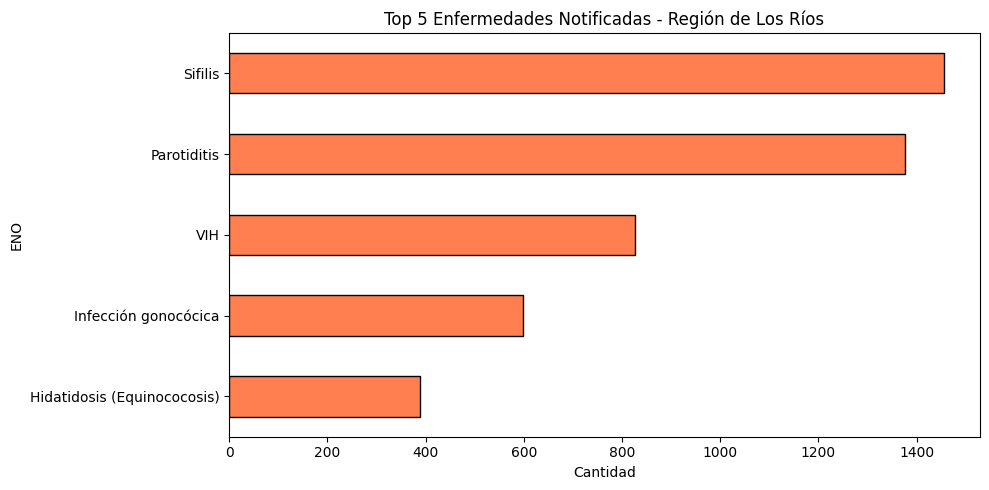


Distribución de Nacionalidades en Los Ríos (incluyendo Desconocido):
nacionalidad
Desconocido    2818
Chile          2588
Extranjero      175
Name: count, dtype: int64


In [3]:
# 2.1 Load
eno = pd.read_csv("20241218_base_eno_final.csv", sep=";", encoding="utf-8-sig")
print(f"Total rows (Nacional ENO): {len(eno):,}")

# 2.2 Filter to your region (Búsqueda flexible para evitar problemas de exactitud)
eno_region = eno[eno["region"].str.contains("Rios|Ríos", case=False, na=False)]
print(f"Rows in my region (ENO): {len(eno_region):,}")

# 2.3 Notifications by year
notificaciones_por_anio = eno_region["anho_notificacion"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
notificaciones_por_anio.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Notificaciones por Año - Región de Los Ríos")
plt.xlabel("Año")
plt.ylabel("Cantidad de Notificaciones")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2.4 Top 5 diseases
top_5_enfermedades = eno_region["ENO"].value_counts().head(5)

plt.figure(figsize=(10, 5))
top_5_enfermedades.sort_values().plot(kind="barh", color="coral", edgecolor="black")
plt.title("Top 5 Enfermedades Notificadas - Región de Los Ríos")
plt.xlabel("Cantidad")
plt.tight_layout()
plt.show()

# 2.5 Nationality distribution
print("\nDistribución de Nacionalidades en Los Ríos (incluyendo Desconocido):")
print(eno_region["nacionalidad"].value_counts(dropna=False))

### Part 3: GRD — Hospital Discharges

Importancia del Código Ejecutado

- Lectura directa desde ZIP y uso de usecols: El dataset GRD pesa mucho y tiene 129 columnas. Al indicarle a Pandas que lea el archivo .txt directamente desde el .zip y extraiga solo 8 columnas usando usecols, redujimos el consumo de memoria sustancialmente. Sin esto, la sesión de Colab habría colapsado.

- Filtro geográfico indirecto: En el mundo real, las bases de datos casi nunca se comunican bien entre sí. Como el archivo GRD no traía la columna "Región" , tuvimos que inyectar conocimiento externo (nuestra lista de comunas) y usar el método .isin() para "pescar" únicamente los registros de Los Ríos.

- Cruce de datos relacionales (merge / Join): Los médicos no registran "Catarata" en los sistemas, registran el código CIE-10 (ej. H25.1). El código que ejecutaste tomó tu tabla de egresos y la cruzó con el "diccionario" CIE-10  para traducir automáticamente esos códigos en diagnósticos legibles por humanos. Sin este paso, tu gráfico solo mostraría códigos alfanuméricos incomprensibles.

Análisis de tu Output

- Validación de Volumen: El código procesó 1,085,813 egresos a nivel nacional. De ese inmenso total, la Región de Los Ríos representó 20,795 egresos hospitalarios en el sistema público para ese año.

- Análisis del Top 5 Clínico:

Catarata senil nuclear: Es el líder (casi 1,000 casos). Esto refleja una población regional probablemente está envejeciendo.

Cálculo de la vesícula biliar: Chile tiene una de las tasas más altas del mundo de problemas a la vesícula. Que esté en segundo lugar es mas que esperable.

Apendicitis aguda: A diferencia de las dos primeras (que se pueden programar), la apendicitis es la urgencia quirúrgica clásica por excelencia. Es constante, impredecible y requiere hospitalización inmediata, por lo que siempre lidera los conteos de egresos en cualquier región.

Venas varicosas y Convalecencia: Cierran el top 5 confirmando nuevamente que gran parte del volumen de camas de un hospital regional se destina a cirugías programadas (várices) y al cuidado postoperatorio de las mismas.

Total discharges (Nacional GRD): 1,085,813
Discharges in my region (GRD): 20,795


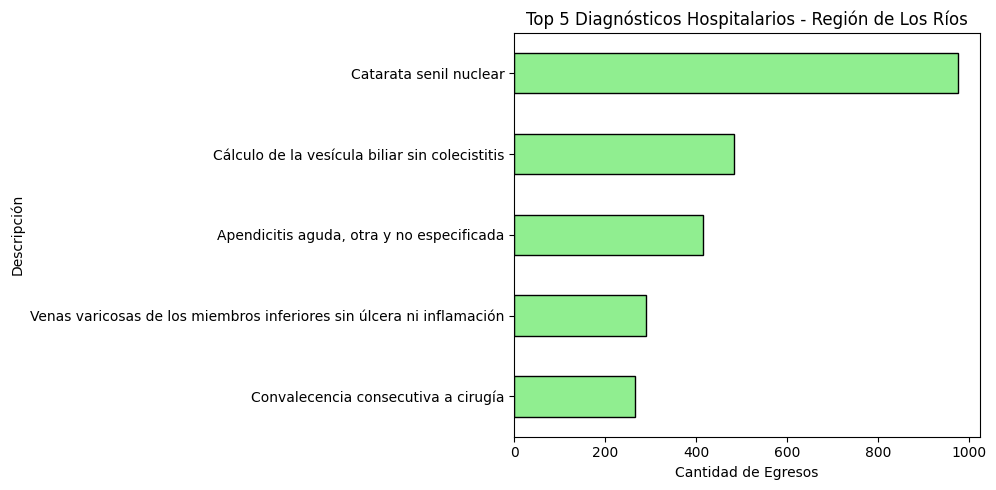

In [5]:
# 3.1 Load one year
cols_grd = ["COMUNA", "NACIONALIDAD", "SEXO", "DIAGNOSTICO1", "FECHA_INGRESO", "FECHAALTA", "IR_29301_SEVERIDAD", "IR_29301_COD_GRD"]

with zipfile.ZipFile("GRD_PUBLICO_2024.zip") as z:
    with z.open("GRD_PUBLICO_2024.txt") as f:
        # Usamos low_memory=False para evitar warnings por tipos de datos mixtos
        grd = pd.read_csv(f, sep="|", usecols=cols_grd, low_memory=False, encoding="latin-1")

print(f"Total discharges (Nacional GRD): {len(grd):,}")

# 3.2 Filter to your region (Filtrando por comunas de Los Ríos en mayúsculas)
my_comunas = ["VALDIVIA", "CORRAL", "LANCO", "LOS LAGOS", "MAFIL", "MARIQUINA", "PAILLACO", "PANGUIPULLI", "LA UNION", "FUTRONO", "LAGO RANCO", "RIO BUENO"]
grd_region = grd[grd["COMUNA"].isin(my_comunas)]
print(f"Discharges in my region (GRD): {len(grd_region):,}")

# 3.3 Join with CIE-10
cie10 = pd.read_excel("CIE-10.xlsx", sheet_name="CIE 10")
grd_region = grd_region.merge(
    cie10[["Código", "Descripción", "Capítulo"]],
    left_on="DIAGNOSTICO1", right_on="Código",
    how="left"
)

# 3.4 Top 5 diagnoses
top_5_diagnosticos = grd_region["Descripción"].value_counts().head(5)

plt.figure(figsize=(10, 5))
top_5_diagnosticos.sort_values().plot(kind="barh", color="lightgreen", edgecolor="black")
plt.title("Top 5 Diagnósticos Hospitalarios - Región de Los Ríos")
plt.xlabel("Cantidad de Egresos")
plt.tight_layout()
plt.show()